# Введение Машинное обучение
### Часть 2

https://scikit-learn.ru/user_guide/

# Соревнование Kaggle "Titanic: Machine Learning from Disaster"

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
df_main = pd.read_csv('data/lesson9/train.csv')
df_test = pd.read_csv('data/lesson9/test.csv')
df_main.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
df_prep_x = df_main.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)
df_prep_x_tst = df_test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df_prep_y = df_main['Survived']

get_dummies - создаем "индикаторные" переменные 1 или 0, тем самым кодируя данные

sex [male, female, ...] -> sex_male [1, 0, 1, ...], sex_female [0, 1, 0, ...]

In [43]:
def prepare_num(df):
    df_num = df.drop(['Sex', 'Embarked', 'Pclass'], axis=1)
    df_sex = pd.get_dummies(df['Sex'])
    df_emb = pd.get_dummies(df['Embarked'], prefix='Emb')
    df_pcl = pd.get_dummies(df['Pclass'], prefix='Pclass')

    df_num = pd.concat((df_num, df_sex, df_emb, df_pcl), axis=1)
    return df_num

In [44]:
df_prep_x_num = prepare_num(df_prep_x)
df_prep_x_num_tst = prepare_num(df_prep_x_tst)
df_prep_x_num.head()

,Age,SibSp,Parch,Fare,female,male,Emb_C,Emb_Q,Emb_S,Pclass_1,Pclass_2,Pclass_3
0,22.0,1,0,7.2500,False,True,False,False,True,False,False,True
1,38.0,1,0,71.2833,True,False,True,False,False,True,False,False
2,26.0,0,0,7.9250,True,False,False,False,True,False,False,True
3,35.0,1,0,53.1000,True,False,False,False,True,True,False,False
4,35.0,0,0,8.0500,False,True,False,False,True,False,False,True


In [45]:
# Заполняем пустые значения
df_prep_x_num = df_prep_x_num.fillna(df_prep_x_num.median())
df_prep_x_num_tst = df_prep_x_num_tst.fillna(df_prep_x_num.median())

Производим нормализацию (Normalization) данных перед использованием в Модели (Model) Машинного обучения (ML)

Мы не можем использовать метод fit () для тестового набора данных,поскольку это может привести к смещению тестового набора данных.

https://stackoverflow.com/questions/23838056/what-is-the-difference-between-transform-and-fit-transform-in-sklearn

In [46]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_x = scaler.fit_transform(df_prep_x_num)
scaled_x_tst = scaler.transform(df_prep_x_num_tst)

# Общий синтаксис моделей sklearn

Конструктор с заданием параметров
```python
model = ...
```

Обучение модели (генерации параметров модели обучения из обучающих данных)
```python
model.fit(X_train, y_train)
```
Предсказание результатов
```python
y_predict = model.predict(X_test)
```


## Обучение без учителя

Конструктор с заданием параметров
```python
model = ...
```

Обучение модели
```python
model.fit(X_train)
```
Трансформация данных (параметры, созданные из fit()метода, применяются к модели для создания преобразованного набора данных)
```python
y_predict = model.transform(X_test)
```
Обучение+трансформация данных
```python
y_predict = model.fit_transform(X_train)
```

## Пример:
## Z  = (x -μ )/ σ

__Fit()__: метод вычисляет параметры μ и σ и сохраняет их как внутренние объекты.
 __Transform()__: метод, использующий эти вычисляемые параметры, применяет преобразование к определенному набору данных.

# Метод главных компонент (PCA)

Метод главных компонент позволяет одновременно избавиться от сильно скоррелированных признаков, так как вектора базиса пространства, на которое они проецируются, будут ортогональными.

https://habr.com/ru/company/ods/blog/325654/

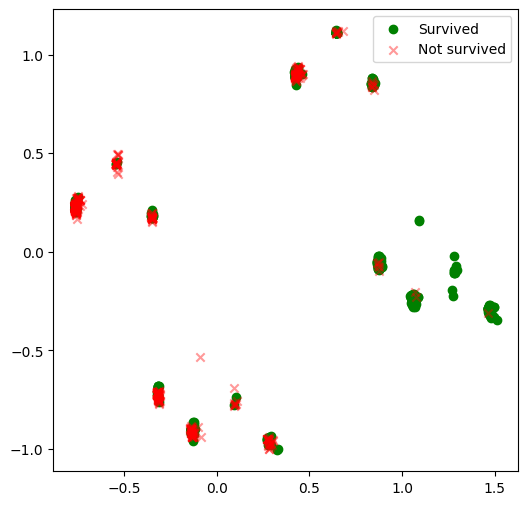

In [47]:
from sklearn.decomposition import PCA

model = PCA(n_components=2)
squeezed = model.fit_transform(scaled_x)

plt.figure(figsize=(6, 6))
plt.scatter(squeezed[df_prep_y == 1][:, 0], squeezed[df_prep_y == 1][:, 1], color='green', label='Survived')
plt.scatter(squeezed[df_prep_y == 0][:, 0], squeezed[df_prep_y == 0][:, 1], color='red', marker='x', alpha=0.4,
           label='Not survived')
plt.legend()
plt.show()

# t-SNE
t-SNE (t-distributed Stohastic Neighbor Embedding), метод отображения из многомерного признакового пространства на плоскость (или в 3D), чтобы точки, которые были далеко друг от друга, на плоскости тоже оказались удаленными, а близкие точки – также отобразились на близкие.

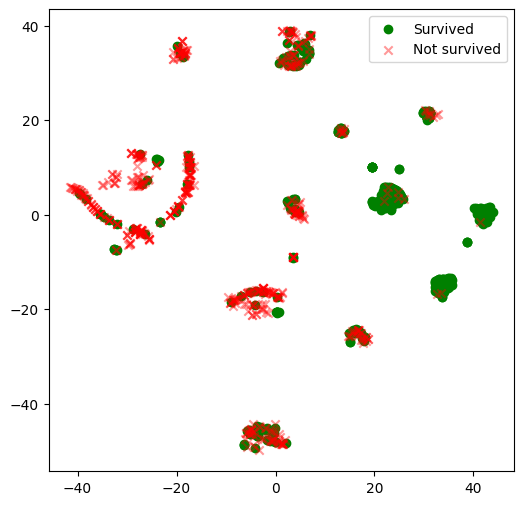

In [48]:
from sklearn.manifold import TSNE

model = TSNE(n_components=2)
squeezed = model.fit_transform(scaled_x)

plt.figure(figsize=(6, 6))
plt.scatter(squeezed[df_prep_y == 1][:, 0], squeezed[df_prep_y == 1][:, 1], color='green', label='Survived')
plt.scatter(squeezed[df_prep_y == 0][:, 0], squeezed[df_prep_y == 0][:, 1], color='red', marker='x', alpha=0.4,
           label='Not survived')
plt.legend()
plt.show()

# Метод ближайших соседей (k-NN)

Метод k-ближайших соседей (k-nearest neighbors algorithm) — метрический алгоритм для автоматической классификации объектов или регрессии.

Для классификации каждого из объектов тестовой выборки необходимо последовательно выполнить следующие операции:
1. Вычислить расстояние до каждого из объектов обучающей выборки
2. Отобрать  объекты обучающей выборки, расстояние до которых минимально
3. Класс классифицируемого объекта — это класс, наиболее часто встречающийся среди ближайших соседей

https://habr.com/ru/company/ods/blog/322534/

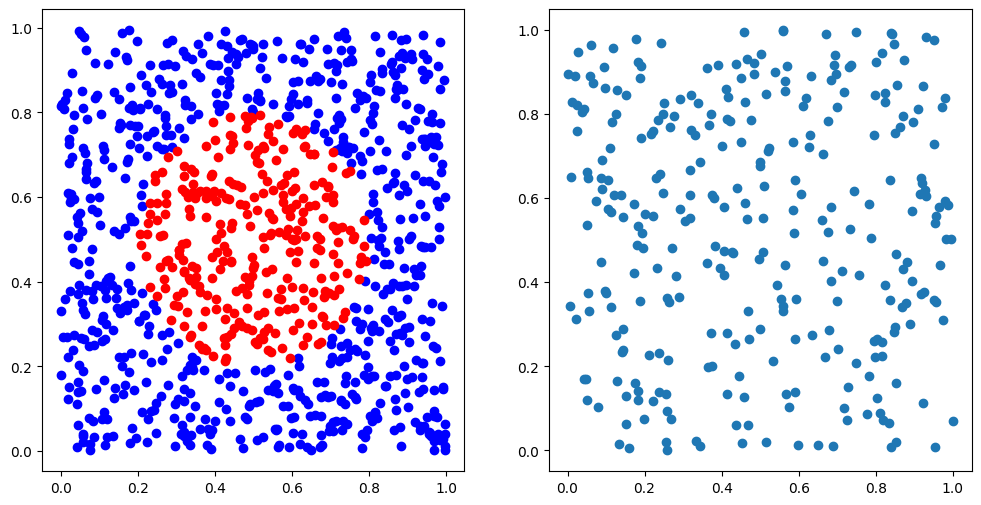

In [49]:
# Сгенерируем данные с 2 признаками
np.random.seed(18182)
data_test = np.random.rand(300, 2)
data_train = np.random.rand(1000, 2)
# Обозначим как позитивные данные в радиусе 0.3 от точки (0.5; 0.5)
label_train = (((data_train - 0.5) ** 2).sum(axis=1) < 0.3 ** 2).astype(float)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(data_train[:, 0][label_train == 0], data_train[:, 1][label_train == 0], color='blue')
plt.scatter(data_train[:, 0][label_train == 1], data_train[:, 1][label_train == 1], color='red')
plt.subplot(1, 2, 2)
plt.scatter(data_test[:, 0], data_test[:, 1])
plt.show()

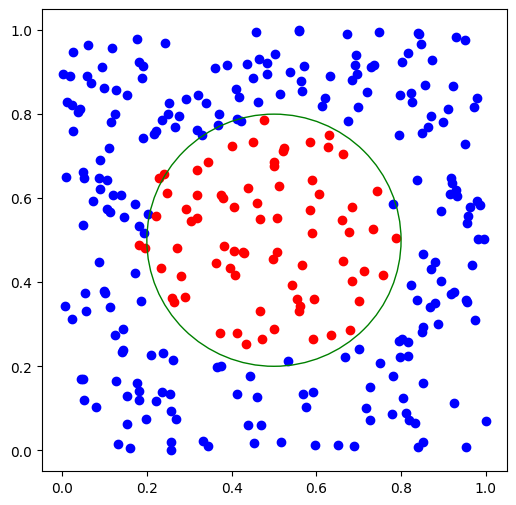

In [50]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(data_train, label_train)
predict = model.predict(data_test)

plt.figure(figsize=(6, 6))
plt.scatter(data_test[:, 0][predict == 0], data_test[:, 1][predict == 0], color='blue')
plt.scatter(data_test[:, 0][predict == 1], data_test[:, 1][predict == 1], color='red')
# Отрисовка круга происходит через создание фигуры и добавления её на график
circle = plt.Circle((0.5, 0.5), 0.3, color='g', fill=False)
plt.gcf().gca().add_artist(circle)
plt.show()

# Дерево решений (Decision Tree)

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model = DecisionTreeClassifier(max_depth=3, criterion='entropy')
model.fit(df_prep_x_num, df_prep_y)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


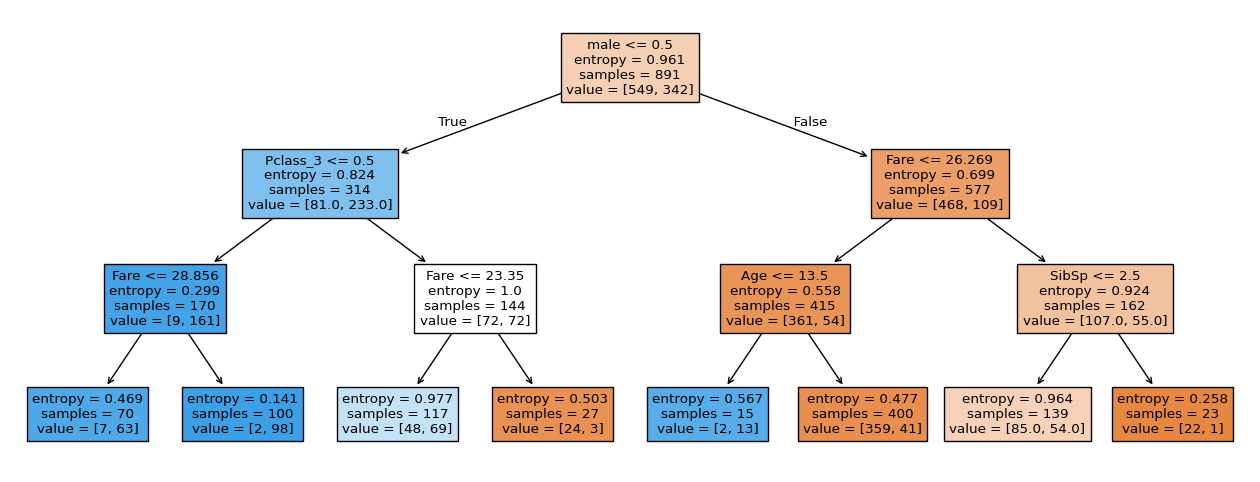

In [52]:
plt.figure(figsize=(16, 6))
tree.plot_tree(model, feature_names=df_prep_x_num.columns, filled=True)
plt.show()

### Энтропия (степень хаоса или неопределенности в системе)
$$
S = -{\sum_{n}p_ilog_2p_i}
$$
n - число классов  
$p_i$ - вероятность i класса
$$
p_0 = {549 \over 891} = 0.6161
$$  

$$
p_1 = {342 \over 891} = 0.3838
$$


$$
S_0 =  -p_0log_2p_0 - p_1log_2p_1 = 0.9607
$$

### Прирост информации
$$
IG = S_0 - \sum_q{N_i\over N}S_i
$$
q - число групп после разбиения  
$N_i$ – число элементов выборки

$$
IG = 0.9607 - {314\over891}*0.824 - {577\over891}*0.699 = 0.2176
$$

### Важность признаков

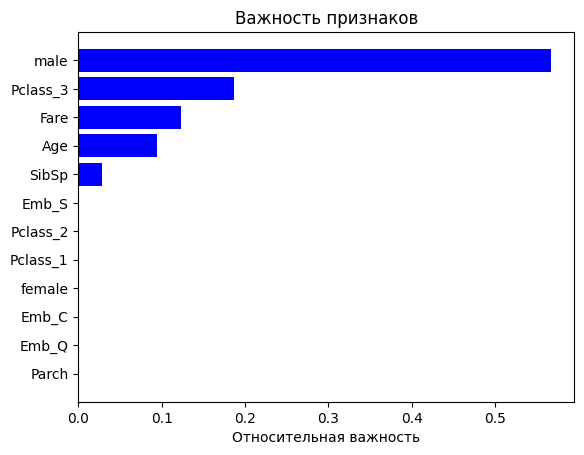

In [53]:
importances = model.feature_importances_
features = df_prep_x_num.columns
# Добавление сортировки по важности
indices = np.argsort(importances)

plt.title('Важность признаков')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), features[indices])
plt.xlabel('Относительная важность')
plt.show()

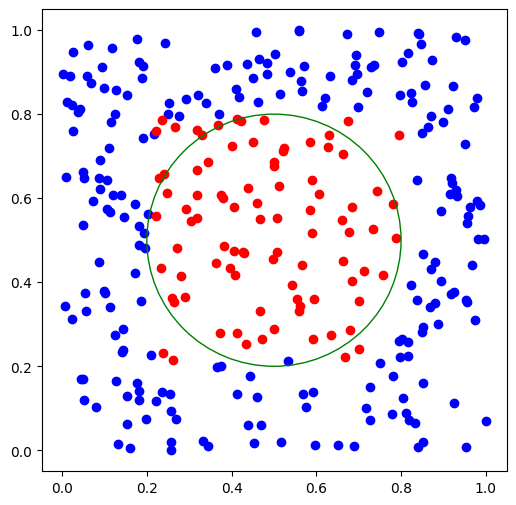

In [54]:
model = DecisionTreeClassifier(max_depth=4, criterion='entropy')
model.fit(data_train, label_train)
predict = model.predict(data_test)

plt.figure(figsize=(6, 6))
plt.scatter(data_test[:, 0][predict == 0], data_test[:, 1][predict == 0], color='blue')
plt.scatter(data_test[:, 0][predict == 1], data_test[:, 1][predict == 1], color='red')
# Отрисовка круга происходит через создание фигуры и добавления её на график
circle = plt.Circle((0.5, 0.5), 0.3, color='g', fill=False)
plt.gcf().gca().add_artist(circle)
plt.show()

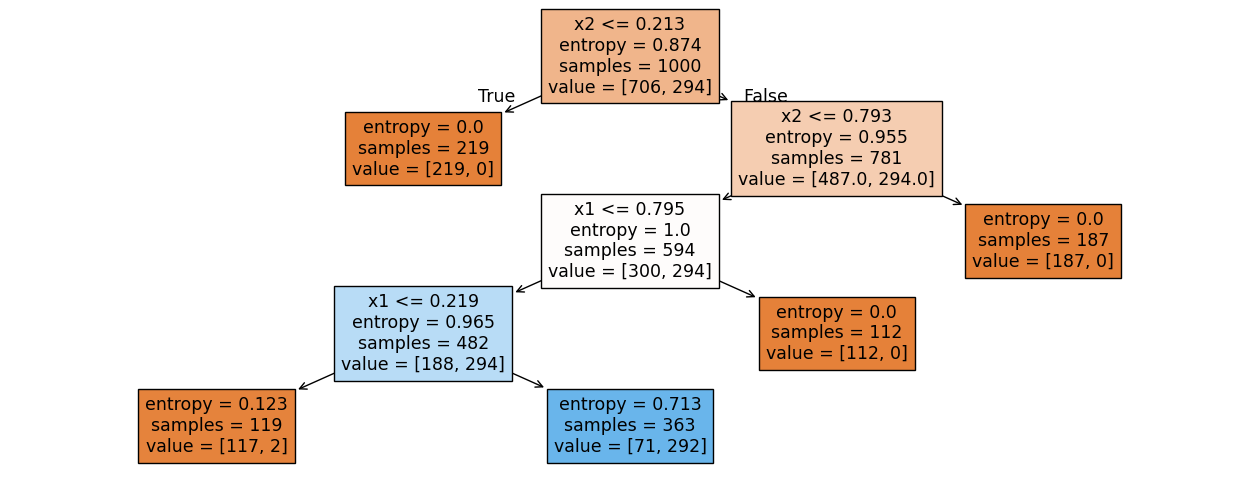

In [55]:
plt.figure(figsize=(16, 6))
tree.plot_tree(model, feature_names=['x1', 'x2'], filled=True)
plt.show()

# Линейная регрессия

<img src="images/LessonsI/extrap.png" alt="Synaps" height=30% width=30%>

$$
y = w_0 + \sum_{i=1}^m w_ix_i
$$

$$x_0 = 1$$

$$
y = \sum_{i=0}^m w_ix_i
$$

$$
\vec{y} = X \vec{w} + \epsilon
$$

$\vec{y}$ – объясняемая (или целевая) переменная  
$\vec{w}$ – вектор параметров модели (веса)  
X – матрица признаков  
$\epsilon$ –  случайная переменная, соответствующая случайной, непрогнозируемой ошибке модели

### Ошибка модели
Метод наименьших квадратов - минимизация среднеквадратичной ошибки между реальным значением зависимой переменной и прогнозом, выданным моделью:
$$
L(X, \vec{y}, \vec{w}) = {1\over2n}\sum_{i=1}^n(y_i-\vec{w}^T\vec{x}_i)^2 = {1\over2n} ||\vec y - X \vec w||_2^2
$$

$$
{\partial L \over \partial \vec w} = 0
$$

### Регуляризация
w может принимать большие значения, что приведёт к нестабильной оценке параметров модели, т.е. добавление нового наблюдения в набор тренировочных данных приведёт к совершенно другому решению. Одним из способов борьбы с этим является регуляризация. Один из вариантов - регуляризация Тихонова:
$$
L(X, \vec{y}, \vec{w}) = {1\over2n} ||\vec y - X \vec w||_2^2 + ||\Gamma \vec w || ^2
$$

$\Gamma$ - матрица Тихонова (коэффициент регуляризации)

https://habr.com/ru/company/ods/blog/323890/

In [56]:
# Пример
df_lr = pd.DataFrame(data={'x':[0.7, 1.3, 2.0, 2.9, 3.4, 5],
                           'y':[0.2, 0.3, 1.1, 1.9, 2.7, 3]})

In [57]:
from ipywidgets import interactive

def loss(m, b):
    df_lr['y_pred'] = m*df_lr['x'] + b
    df_lr['loss'] = np.absolute(df_lr['y']-df_lr['y_pred'])
    print('loss =', df_lr['loss'].mean())

def plot(m, b):
    plt.figure(2)
    x = np.linspace(0, 6, num=1000)
    plt.plot(x, m * x + b)
    plt.scatter(x=df_lr['x'], y=df_lr['y'])
    plt.ylim(-0.5, 3.4)
    plt.grid()
    plt.show()
    loss(m, b)

interactive_plot = interactive(plot, m=(-2.0, 2.0), b=(-3, 3, 0.1))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

ModuleNotFoundError: No module named 'ipywidgets'

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df_lr[['x']], df_lr[['y']])
f'm = {model.coef_} b = {model.intercept_}' 

'm = [[0.73836012]] b = [-0.34948496]'

# Логистическая регрессия

![sklearn clustering](https://habrastorage.org/r/w1560/getpro/habr/post_images/555/369/344/5553693449d97a6ccb730f4760a2eacd.png)

Линейный классификатор:
$$
a(\vec x) = sign(\vec w^Tx)
$$
sign() - функция, возвращающая знак своего аргумента  
$a(\vec x)$ - ответ классификатора (1 - целевой клас, -1 - отрицательный пример)  

Логистическая регрессия является частным случаем линейного классификатора, но она может выражать вероятность отнесения функции к положительному классу ($p_+$):
$$
p_+ = P(y_i = 1| \vec x_i, \vec w)
$$
P(X) - вероятность события X

$f(\vec x_i, \vec w) = \vec x_i \vec w = 0$ - разделяющая плоскость  
f > 0 - класс "+"  
f < 0 - класс "-"  
f = 0 - неопределённость  

Но данные функции имеют разные пределы:  
$f \in (-\infty ; \infty)$  
$P \in [0 ; 1]$

Введём функцию отношения вероятностей:
$$
OR(X) = {P(X) \over 1 - P(X)}
$$
$OR \in (0 ; \infty)$, а $ln(OR) \in (-\infty ; \infty)$

Таким образом
$log(OR_+) = \vec w^T \vec x_i $ или $OR_+ = e^{\vec w^T \vec x_i }$

$$
p_+ = {OR_+ \over 1 + OR_+} = {e^{\vec w^T \vec x_i } \over 1 + e^{\vec w^T \vec x_i }} = {1 \over 1 + e^{-\vec w^T \vec x_i }} = \sigma(\vec w^T \vec x_i )
$$
$\sigma(x)$ - сигмоид-функция 
![sigmoid](https://upload.wikimedia.org/wikipedia/commons/a/ac/Logistic-curve.png)

Вероятность отнесения функции к отрицательному классу:
$$
p_- = P(y_i = -1| \vec x_i, \vec w) = \sigma(-\vec w^T \vec x_i  )
$$

Обобщение:
$$
P(y = y_i| \vec x_i, \vec w) = \sigma(y_i\vec w^T \vec x_i  )
$$

In [ ]:
# Пример
df_lgr = pd.DataFrame(data={'x':[0.7, 1.3, 2.0, 2.9, 3.4, 5],
                            'y':[0., 0., 1., 0., 1., 1]})

In [ ]:
def loss_P(m, b):
    # Принцип максимального правдоподобия
    # Стараемся, чтобы "правдоподобия", рассчитанных для каждой точки
    # были максимальны
    df_lgr['y_pred'] = 1/(1 + np.exp(-(m * df_lgr['x'] + b)))
    # События независимы, поэтому их общая вероятность
    # равна произведению П P(y=y_i | x_i,w)
    df_lgr['P'] = df_lgr['y_pred'][df_lgr['y']==1] # вероятность, что y_i = 1
    df_lgr['P'][df_lgr['y']==0] = 1-df_lgr['y_pred']  # вероятность, что y_i = 0
    P=1
    for x in df_lgr['P']:
        P *= x
    print('П P_i =', P)

def loss_log_P(m, b):
    # Принцип максимального правдоподобия
    # Избавимся от произведения вероятностей -> Перейдём к сумме log-ов
    # Необходимо минимизировать выражение:
    df_lgr['y_pred'] = 1/(1 + np.exp(-(m * df_lgr['x'] + b)))
    df_lgr['log_P'] = np.log(df_lgr['y_pred'][df_lgr['y']==1])
    df_lgr['log_P'][df_lgr['y']==0] = np.log(1-df_lgr['y_pred'])
    print('SUM log(P_i) =', df_lgr['log_P'].sum())
    

def plot(m, b):
    plt.figure(2)
    x = np.linspace(0, 6, num=1000)
    plt.plot(x, (1/(1 + np.exp(-(m * x + b)))))
    plt.scatter(x=df_lgr['x'], y=df_lgr['y'])
    plt.ylim(-0.1, 1.2)
    plt.grid()
    plt.show()
    loss_P(m, b)
    loss_log_P(m, b)

interactive_plot = interactive(plot, m=(-1.0, 5.0), b=(-10, 0, 0.1))
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot
# Ищем Максимум П P
# и минимум log(P)

interactive(children=(FloatSlider(value=2.0, description='m', max=5.0, min=-1.0), FloatSlider(value=-5.0, desc…

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(df_lgr[['x']], df_lgr[['y']])
f'm = {model.coef_} b = {model.intercept_}' 

/opt/conda/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


'm = [[0.77756094]] b = [-1.94751025]'

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(C=0.1, solver='lbfgs')
model.fit(scaled_x, df_prep_y)

y_pred = model.predict(scaled_x_tst)
print('Классы:', y_pred[:4])
y_proba = model.predict_proba(scaled_x_tst)
print('Вероятности:\n', y_proba[:4])

Классы: [0 1 0 0]
Вероятности:
 [[0.85226449 0.14773551]
 [0.49909854 0.50090146]
 [0.72998682 0.27001318]
 [0.88306963 0.11693037]]


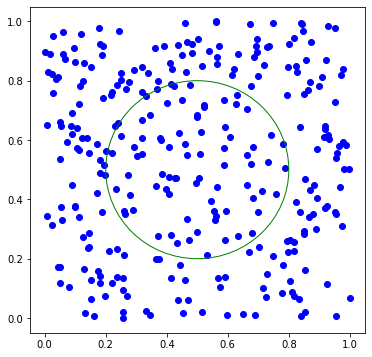

In [ ]:
# В данном случае модель не смогла подобрать разделяющую гиперплоскость
model = LogisticRegression(C=0.1, solver='lbfgs')
model.fit(data_train, label_train)
predict = model.predict(data_test)

plt.figure(figsize=(6, 6))
plt.scatter(data_test[:, 0][predict == 0], data_test[:, 1][predict == 0], color='blue')
plt.scatter(data_test[:, 0][predict == 1], data_test[:, 1][predict == 1], color='red')
# Отрисовка круга происходит через создание фигуры и добавления её на график
circle = plt.Circle((0.5, 0.5), 0.3, color='g', fill=False)
plt.gcf().gca().add_artist(circle)
plt.show()

# Случайный лес
Алгоритм:
1. Сгенерировать подвыборку из данных
2. Построить решающее дерево  по подвыборке
3. Повторить шаги 1, 2 K раз
4. Результат принимается как результат большинства (классификация) или среднему (регрессия)

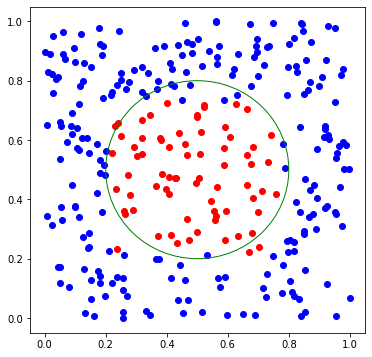

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=20, max_depth=4, criterion='entropy')
model.fit(data_train, label_train)
predict = model.predict(data_test)

plt.figure(figsize=(6, 6))
plt.scatter(data_test[:, 0][predict == 0], data_test[:, 1][predict == 0], color='blue')
plt.scatter(data_test[:, 0][predict == 1], data_test[:, 1][predict == 1], color='red')
# Отрисовка круга происходит через создание фигуры и добавления её на график
circle = plt.Circle((0.5, 0.5), 0.3, color='g', fill=False)
plt.gcf().gca().add_artist(circle)
plt.show()

# XGBoost
Алгоритм для K шага:
1. Сгенерировать подвыборку из данных
2. Построить решающее дерево  по подвыборке. Целевая величина $y - pred_{K-1}$, где $pred_{K-1}$ - предсказание комбинации прошлых деревьев
3. Добавить новое дерево к имеющемуся результату из комбинации прошлых деревьев так, чтобы минимизировать ошибку

[11:05:17] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


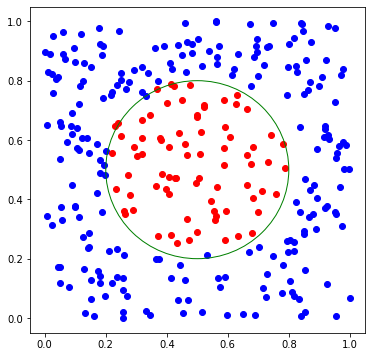

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=20, max_depth=4)
model.fit(data_train, label_train)
predict = model.predict(data_test)

plt.figure(figsize=(6, 6))
plt.scatter(data_test[:, 0][predict == 0], data_test[:, 1][predict == 0], color='blue')
plt.scatter(data_test[:, 0][predict == 1], data_test[:, 1][predict == 1], color='red')
# Отрисовка круга происходит через создание фигуры и добавления её на график
circle = plt.Circle((0.5, 0.5), 0.3, color='g', fill=False)
plt.gcf().gca().add_artist(circle)
plt.show()

# Кластеризация

![sklearn clustering](https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png)

# K-means

Алгоритм:  
1. Выбирается количество кластеров (k)  
2. Случайным образом выбираются k точек, как центры кластеров  
3. Для всех точек выборки определяется к какому центру они ближе  
4. Переместить центры кластеров в центры выборок  
5. Повторять последние два шага фиксированное число раз, либо до тех пор пока центроиды не "сойдутся" (обычно это значит, что их смещение относительно предыдущего положения не превышает какого-то заранее заданного небольшого значения)

https://www.naftaliharris.com/blog/visualizing-k-means-clustering/

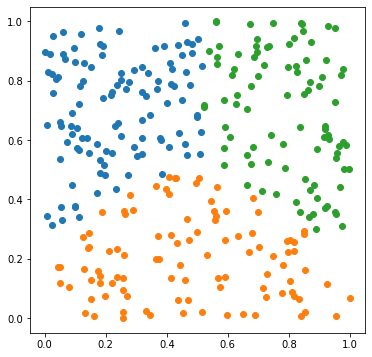

In [ ]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3)
clusters = model.fit_predict(data_test)

plt.figure(figsize=(6, 6))
for cl in np.unique(clusters):
    data_ = data_test[clusters == cl]
    plt.scatter(data_[:, 0], data_[:, 1])
plt.show()

# DBSCAN

Алгоритм DBSCAN (Density-based spatial clustering of applications with noise) рассматривает кластеры как области высокой плотности, разделенные областями низкой плотности. Из-за этого довольно общего представления кластеры, найденные DBSCAN, могут иметь любую форму, в отличие от k-means, которые предполагают, что кластеры имеют выпуклую форму.  
Этот алгоритм позволяет выделять произвольное количество кластеров, основываясь на расстоянии между ними. 

https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/

6 кластеров


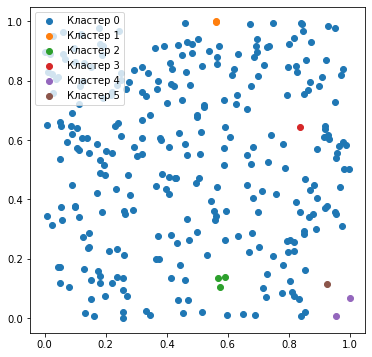

In [ ]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.08, min_samples=1)
clusters = model.fit_predict(data_test)
print(np.unique(clusters).size, 'кластеров')

plt.figure(figsize=(6, 6))
for cl in np.unique(clusters):
    data_ = data_test[clusters == cl]
    plt.scatter(data_[:, 0], data_[:, 1], label='Кластер {}'.format(cl))
plt.legend(loc=2)
plt.show()

хздбю# Ресурсы для углублённого изучения темы

* [Открытый курс машинного обучения Open Data Science](https://habr.com/ru/company/ods/blog/322626/)
* [Видеолекции ШАД Воронцова](https://yandexdataschool.ru/edu-process/courses/machine-learning)
* [Классический курс по машинному обучению. Включает в себя как элементы классического ML так и нейронные сети](https://www.coursera.org/learn/machine-learning)
* [Лекции об инструментах, которые нужны, чтобы начать применять ML на практике](https://www.dataschool.io/)

# Задания

1. Разделите данные Титаника (*train.csv*) на тренировочную, валидационную и тестовую часть. С помощью валидационной части подберите гиперпараметры для моделей Random Forest, XGBoost, Logistic Regression и KNN. Получите точность этих моделей на тестовой части.
2. С помощью RandomForest выберите 2, 4, 8 самых важных признаков и проверьте точность моделей только на этих признаках.

In [58]:
from sklearn.model_selection import train_test_split

def prepare_num(df):
    df_num = df.drop(["Sex", "Embarked", "Pclass"], axis=1)
    df_sex = pd.get_dummies(df["Sex"])
    df_emb = pd.get_dummies(df["Embarked"], prefix="Emb")
    df_pcl = pd.get_dummies(df["Pclass"], prefix="Pclass")
    df_num = pd.concat((df_num, df_sex, df_emb, df_pcl), axis=1)
    return df_num

df = pd.read_csv("/home/julia/Рабочий стол/code/PAC/data/lesson9/train.csv")
X = df.drop(["PassengerId", "Survived", "Name", "Ticket", "Cabin"], axis=1)
y = df["Survived"]
X = prepare_num(X)
X = X.fillna(X.median())

In [59]:
# Assuming a 60-20-20 split (train-val-test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
print(f"Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

Train (534, 12), Val (178, 12), Test (179, 12)


In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
results = {}

In [61]:
# Random Forest
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
rf_val_score = accuracy_score(y_val, best_rf.predict(X_val))
rf_test_score = accuracy_score(y_test, best_rf.predict(X_test))

results["Random Forest"] = {
    "best_params": rf_grid.best_params_,
    "val_score": rf_val_score,
    "test_score": rf_test_score,
}

# XGBoost
xgb_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    xgb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
xgb_val_score = accuracy_score(y_val, best_xgb.predict(X_val))
xgb_test_score = accuracy_score(y_test, best_xgb.predict(X_test))

results["XGBoost"] = {
    "best_params": xgb_grid.best_params_,
    "val_score": xgb_val_score,
    "test_score": xgb_test_score,
}

# Logistic Regression
lr_param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_
lr_val_score = accuracy_score(y_val, best_lr.predict(X_val))
lr_test_score = accuracy_score(y_test, best_lr.predict(X_test))

results["Logistic Regression"] = {
    "best_params": lr_grid.best_params_,
    "val_score": lr_val_score,
    "test_score": lr_test_score,
}

# KNN
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(), knn_param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
knn_val_score = accuracy_score(y_val, best_knn.predict(X_val))
knn_test_score = accuracy_score(y_test, best_knn.predict(X_test))

results["KNN"] = {
    "best_params": knn_grid.best_params_,
    "val_score": knn_val_score,
    "test_score": knn_test_score,
}


for model_name, result in results.items():
    print(f"\n{model_name}:")
    print(f"  Лучшие параметры: {result['best_params']}")
    print(f"  Точность на валидации: {result['val_score']:.4f}")
    print(f"  Точность на тесте: {result['test_score']:.4f}")

best_model_name = max(results.keys(), key=lambda x: results[x]["test_score"])
best_score = results[best_model_name]["test_score"]
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name} с точностью {best_score:.4f}")


Random Forest:
  Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
  Точность на валидации: 0.8090
  Точность на тесте: 0.8045

XGBoost:
  Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.9}
  Точность на валидации: 0.8034
  Точность на тесте: 0.8212

Logistic Regression:
  Лучшие параметры: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
  Точность на валидации: 0.7640
  Точность на тесте: 0.8101

KNN:
  Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
  Точность на валидации: 0.7022
  Точность на тесте: 0.7709
ЛУЧШАЯ МОДЕЛЬ: XGBoost с точностью 0.8212


best_rf - лучшая моедль рандомного леса, которую вообще смог найти GridSearchCV
GridSearchCV перебирал кучу всяких параметров
для каждой комбинайции обучал модель
best_rf те модель с лучшими параметрами обученная на тренировочных данных всех
внутри лежат параметры модели, обученный лес, методы предсказания те predict(), информация о модели включая feature_importances - массив  где каждый элемент показывает важность соответствующего признака. Значения нормированы так, что их сумма равна 1.


теперь нам надо выбрать из всех признаков самые важные


In [63]:
# можно посмотреть что внутри

print("Тип best_rf:", type(best_rf))
print("\nЛучшие параметры модели:")
print(best_rf.get_params())

print("\nДоступные атрибуты:")
print([attr for attr in dir(best_rf) if not attr.startswith("_")])

print("\nЕсть ли feature_importances_?", hasattr(best_rf, "feature_importances_"))

print(best_rf.feature_importances_)

Тип best_rf: <class 'sklearn.ensemble._forest.RandomForestClassifier'>

Лучшие параметры модели:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Доступные атрибуты:
['apply', 'bootstrap', 'ccp_alpha', 'class_weight', 'classes_', 'criterion', 'decision_path', 'estimator', 'estimator_', 'estimator_params', 'estimators_', 'estimators_samples_', 'feature_importances_', 'feature_names_in_', 'fit', 'get_metadata_routing', 'get_params', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'n_classes_', 'n_estimators', 

In [68]:
feature_importances = best_rf.feature_importances_
feature_names = X.columns

#создаем табличку с признаками
feat_imporat_df = pd.DataFrame({ 'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)
print(feat_imporat_df)

     feature  importance
5       male    0.288454
4     female    0.234689
3       Fare    0.108982
0        Age    0.096618
11  Pclass_3    0.083650
1      SibSp    0.040678
9   Pclass_1    0.040389
2      Parch    0.029649
8      Emb_S    0.027814
10  Pclass_2    0.023821
6      Emb_C    0.018258
7      Emb_Q    0.006998


In [69]:
top_2_features = feat_imporat_df["feature"].head(2).tolist()
top_4_features = feat_imporat_df["feature"].head(4).tolist()
top_8_features = feat_imporat_df["feature"].head(8).tolist()

print(top_2_features, top_4_features, top_8_features, sep = "\n")
#дальше надо переобучить все модели только на этих features

['male', 'female']
['male', 'female', 'Fare', 'Age']
['male', 'female', 'Fare', 'Age', 'Pclass_3', 'SibSp', 'Pclass_1', 'Parch']


In [78]:
# Random Forest, XGBoost, Logistic Regression и KNN
def evaluate_models_on_features(selected_features, feature_set_name):

    # Выбираем только нужные признаки
    X_train_selected = X_train[selected_features]
    X_val_selected = X_val[selected_features]
    X_test_selected = X_test[selected_features]

    results_selected = {}

    # Random Forest с лучшими параметрами
    best_rf_selected = RandomForestClassifier(
        **rf_grid.best_params_, random_state=42
    )  # **rf_grid.best_params_  используем те же самые лучшие параметры, что мы нашли ранее через GridSearch
    best_rf_selected.fit(X_train_selected, y_train)
    rf_val_score = accuracy_score(y_val, best_rf_selected.predict(X_val_selected))
    rf_test_score = accuracy_score(y_test, best_rf_selected.predict(X_test_selected))
    results_selected["Random Forest"] = {
        "val_score": rf_val_score,
        "test_score": rf_test_score,
    }
    best_xgb_selected = XGBClassifier(
        **xgb_grid.best_params_, random_state=42, eval_metric="logloss")
    best_xgb_selected.fit(X_train_selected, y_train)
    xgb_val_score = accuracy_score(y_val, best_xgb_selected.predict(X_val_selected))
    xgb_test_score = accuracy_score(y_test, best_xgb_selected.predict(X_test_selected))
    results_selected["XGBoost"] = {
        "val_score": xgb_val_score,
        "test_score": xgb_test_score,
    }
    best_lr_selected = LogisticRegression(**lr_grid.best_params_, random_state=42, max_iter=1000)
    best_lr_selected.fit(X_train_selected, y_train)
    lr_val_score = accuracy_score(y_val, best_lr_selected.predict(X_val_selected))
    lr_test_score = accuracy_score(y_test, best_lr_selected.predict(X_test_selected))
    results_selected["Logistic Regression"] = {
        "val_score": lr_val_score,
        "test_score": lr_test_score,
    }
    best_knn_selected = KNeighborsClassifier(**knn_grid.best_params_,)
    best_knn_selected.fit(X_train_selected, y_train)
    knn_val_score = accuracy_score(y_val, best_knn_selected.predict(X_val_selected))
    knn_test_score = accuracy_score(y_test, best_knn_selected.predict(X_test_selected))
    results_selected["KNN"] = {
        "val_score": knn_val_score,
        "test_score": knn_test_score,
    }
    return results_selected

In [79]:
results_2_features = evaluate_models_on_features(
    top_2_features, "2 самых важных признака"
)
results_4_features = evaluate_models_on_features(
    top_4_features, "4 самых важных признака"
)
results_8_features = evaluate_models_on_features(
    top_8_features, "8 самых важных признака"
)


print(
    f"\n{'Модель':<20} {'Все признаки':<12} {'8 признаков':<12} {'4 признака':<12} {'2 признака':<12}"
)
for model_name in results.keys():
    original_score = results[model_name]["test_score"]
    score_8_features = results_8_features[model_name]["test_score"]
    score_4_features = results_4_features[model_name]["test_score"]
    score_2_features = results_2_features[model_name]["test_score"]

    print(
        f"{model_name:<20} {original_score:<12.4f} {score_8_features:<12.4f} {score_4_features:<12.4f} {score_2_features:<12.4f}"
    )


Модель               Все признаки 8 признаков  4 признака   2 признака  
Random Forest        0.8045       0.8101       0.7933       0.7989      
XGBoost              0.8212       0.8045       0.7933       0.7989      
Logistic Regression  0.8101       0.8212       0.7933       0.7989      
KNN                  0.7709       0.7709       0.7151       0.7989      


# Лабораторная работа 9. Титаник ML
Для выполнения лабораторной необходимо скачать подготовленный [файл](https://drive.google.com/file/d/1BB__BNUiX4uS7obrGsv4rcOMB26Cr5Pb/view?usp=sharing) для задачи про Титаник: 

Необходимо использовать именно этот файл, а не из *Лабораторной #5*, так как в этом другие значения столбца label.


## Лабораторная 9.1

1. Загрузить файл, разделить его на train и test. Для test взять 10% случайно выбранных строк таблицы.
2. Обучить модели: Decision Tree, XGBoost, Logistic Regression из библиотек sklearn и xgboost. Обучить модели предсказывать столбец label по остальным столбцам таблицы.
3. Наладить замер Accuracy - доли верно угаданных ответов.
4. Точности всех моделей не должны быть ниже 85%
5. С помощью Decision Tree выбрать 2 самых важных признака и проверить точность модели, обученной только на них.

## Лабораторная 9.2

1. Лабораторная 9.1 пп.1-5
2. Реализовать случайный лес в виде класса MyRandomForest. В реализации разрешается использовать DecisionTreeClassifier из библиотеки sklearn. Класс должен иметь методы fit и predict по аналогии с остальными классами библиотеки sklearn.  
    Алгоритм построения Случайного леса изложен на [Википедии](https://ru.wikipedia.org/wiki/Random_forest)  
    Необходимо обратить внимание что при построения леса используются не все доступные признаки для каждого узла дерева. А так же что в sklearn это регулируется параметрами DecisionTreeClassifier.
3. Продемонстрировать, что точность леса выше чем точность одного решающего дерева.
